## TCG ML PRIMER ##

**Contents:** 

Helloooooo analysts. Below is a breakdown of what you will learn through completing this primer, the fundamental Data Science - Machine Learning process, and how this will prepare you to build a model for a real client. 

---

# Table of Contents 

## 1. Problem definition

1. meaningful problem that has some real world application versus basic analysis 

---

## 2. Loading the Dataset 

---

## 3. Exploratory Data Analysis (EDA)

1. understanding the data in each column 

2. what features might influence what you’re measuring in your question 

3. columns → features (what features are important? why?)

---

## 4. Data Cleaning 

1. clean vs messy data (what is the difference) 

2. how do you handle missing values? 

3. how do you decide what makes data “easier to work with”?

4. how do you standardize data to make it easy to work with? how do you handle inconsistent formats? 

5. how do you deal with duplicate values? 

6. outliers? 

---

## 5. Feature Engineering 

1. encoding variables? why and how do we do it? 

2. feature scaling/standardization

3. creating new features out of old features? 

4. how do we choose which features we need? 

---

## 6. Train/Test Split 

1. why do we split data? 

2. how do we train a model vs testing a model? 

---

## 7. Model Selection and Training 

1. Linear Regression, Logistic Regression, Decision Trees 

2. Classification vs Regression 

3. bias vs variance 

4. underfitting and overfitting 

---

## 8. Model Evaluation 

1. Which metrics should we use? How do we evaluate how good our model is at predicting xyz value? 

2. Regression: MAE, MSE, RMSE

3. Classification: Accuracy, precision, recall, F1 

4. confusion matrix 

---

## 9. Cross-Validation 

1. is one train test split all we need? 

2. k-fold cross validation 

---

## 10. Hyperparameter Tuning 

1. what is a hyper parameter? why are they important to us? 

2. Grid Search vs Random Search 

---

## 11. Model Interpretation 

1. feature importance 

2. why is the model predicting this?

---

## 12. Analysis and Communication

1. interpreting results in plain english

2. what are the business implications of this analysis? 

3. how does this model’s predictions improve xyz? 

4. This is where the real consulting starts, next step is putting all this analysis into a visual aid that can help your client (who knows nothing about data science) understand why this will help them solve the problem they’ve reached out to you and TCG to solve! (hint: slide deck time)

---

# STEP 0: Imports # 

*These are the imports you should need to complete this primer, you will soon see what each of these is used for and why they are necessary to create a machine learning model*


In [40]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## STEP 1: Question ##

**TODO: Come up with a meaningful data science question + pick a dataset!**

Kaggle has a bunch of open source (ie open for public use) datasets for you to choose from here: https://www.kaggle.com/datasets pick one that speaks to you. This one with information on coffee sales spoke to me : https://www.kaggle.com/datasets/ihelon/coffee-sales 

We want to answer a certain question about the data we are being given. Think about what you want to find out about the data you are looking at. If a business were to give you this data and they wanted to improve something about how they were running, what question would they ask? Depending on the dataset, the range of analysis you could do or questions you could ask is infinite, so think about what the data could actually mean. 

Example: You are given a dataset containing all of the orders (and the necessary info about them ie time place, order placed by who, order contents, nutritional info, etc) that were made at Audrey’s in Geisel during finals week, meaningful data science questions would include → 

- Does time of day affect how much caffeine people get in their drinks? 

- Are students more likely to order unhealthy foods at night? 

- Can we predict what someone will order based on the time of day? <-- For this notebook, we'll be using this question! (note: the dataset we're using in NOT from Audrey's, just a normal coffee shop) 

Once you come up with a question, start brainstorming what columns in your dataset might help you answer it!!

## STEP 2: Loading the Dataset ## 

In [2]:
df = pd.read_csv("/Users/nikithakerudi/Downloads/archive 2/index_1.csv")
df.loc[df.sample(frac = 0.05).index, "coffee_name"] = np.nan
'''This dataset was a little too clean so for the purposes of teaching you guys data cleaning, this line above add some random null
values so we can see how to deal with them! (most data you encounter in the real world WILL NOT be clean)'''
df 



,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.70,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.70,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.70,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.90,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.70,Latte
...,...,...,...,...,...,...
3631,2025-03-23,2025-03-23 10:34:54.894,card,ANON-0000-0000-1158,35.76,Cappuccino
3632,2025-03-23,2025-03-23 14:43:37.362,card,ANON-0000-0000-1315,35.76,Cocoa
3633,2025-03-23,2025-03-23 14:44:16.864,card,ANON-0000-0000-1315,35.76,Cocoa
3634,2025-03-23,2025-03-23 15:47:28.723,card,ANON-0000-0000-1316,25.96,NaN


## STEP 3: EDA ## 
First take a good look at your dataset: 
- What columns are there? 
- What does each column tell us? 
- Which columns relate to our problem/question? 
- Are any columns unnecessary? If so, what do we do with them? 


*Below are some common pandas methods to gain more information about your dataset without looking through each and every row/column!*

In [3]:
df.info() # note: in "coffee_name" we made sure about 5% of values are null, see how the non-null count is lower in that column! 

# (df.shape returns (3636, 6) -> 3636 total rows meaning those with 3636 non-null values are columns with no null values)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3636 non-null   object 
 1   datetime     3636 non-null   object 
 2   cash_type    3636 non-null   object 
 3   card         3547 non-null   object 
 4   money        3636 non-null   float64
 5   coffee_name  3454 non-null   object 
dtypes: float64(1), object(5)
memory usage: 170.6+ KB


In [4]:
df.describe()

,money
count,3636.000000
mean,31.746859
std,4.919926
min,18.120000
25%,27.920000
50%,32.820000
75%,35.760000
max,40.000000


In [5]:
df.columns # returns columns as an array


Index(['date', 'datetime', 'cash_type', 'card', 'money', 'coffee_name'], dtype='object')

In [6]:
df.loc[0][0] #date column shows date as a string 

/var/folders/rd/rv0859t50gqf0xnbs_4ffty80000gn/T/ipykernel_43509/2890983164.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.loc[0][0] #date column shows date as a string


'2024-03-01'

In [7]:
df.loc[0][1] #datetime column can easily be made into -> datetime object 

/var/folders/rd/rv0859t50gqf0xnbs_4ffty80000gn/T/ipykernel_43509/1228516380.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.loc[0][1] #datetime column can easily be made into -> datetime object


'2024-03-01 10:15:50.520'

Here we can see our columns are 'date', 'datetime', 'cash_type', 'card', 'money', 'coffee_name'. Going back to our original question of : "Can we predict what someone will order based on the time of day?" what columns do you think are relevant here? 

Answer: #TODO

### Lets explore a little more about this data ### 

Specifically let's look at: 

1. How much of each coffee drink is sold? 
2. Are some values missing? If so, where? What do we do with them? 
3. What types of values are we seeing in each column? 

Below are some useful EDA techniques: 

In [10]:
print(df.head()) # shows first 5 rows of the dataset


         date                 datetime cash_type                 card  money  \
0  2024-03-01  2024-03-01 10:15:50.520      card  ANON-0000-0000-0001   38.7   
1  2024-03-01  2024-03-01 12:19:22.539      card  ANON-0000-0000-0002   38.7   
2  2024-03-01  2024-03-01 12:20:18.089      card  ANON-0000-0000-0002   38.7   
3  2024-03-01  2024-03-01 13:46:33.006      card  ANON-0000-0000-0003   28.9   
4  2024-03-01  2024-03-01 13:48:14.626      card  ANON-0000-0000-0004   38.7   

     coffee_name  
0          Latte  
1  Hot Chocolate  
2  Hot Chocolate  
3      Americano  
4          Latte  


In [11]:
print(df.sample(5)) # shows 5 random rows of the dataset (useful for getting a quick look at the data)


            date                 datetime cash_type                 card  \
1916  2024-10-13  2024-10-13 20:43:04.928      card  ANON-0000-0000-0257   
2666  2024-12-29  2024-12-29 20:25:54.231      card  ANON-0000-0000-1058   
1145  2024-08-02  2024-08-02 09:01:54.165      card  ANON-0000-0000-0453   
1659  2024-09-23  2024-09-23 19:47:21.950      card  ANON-0000-0000-0507   
1024  2024-07-24  2024-07-24 09:54:37.456      card  ANON-0000-0000-0402   

      money          coffee_name  
1916  35.76           Cappuccino  
2666  35.76        Hot Chocolate  
1145  27.92  Americano with Milk  
1659  32.82                Latte  
1024  18.12                  NaN  


In [12]:
print(df.isnull().sum()) # shows number of null values in each column (useful for data cleaning)


date             0
datetime         0
cash_type        0
card            89
money            0
coffee_name    182
dtype: int64


In [ ]:
print(df.nunique()) #shows number of unique values in each column (useful for understanding categorical variables)


date            381
datetime       3636
cash_type         2
card           1316
money            20
coffee_name       8
dtype: int64


In [14]:
print(df["coffee_name"].value_counts()) # shows count of each unique value in the "coffee_name" column (useful for understanding distribution of categorical variable)

coffee_name
Americano with Milk    788
Latte                  746
Americano              554
Cappuccino             472
Cortado                274
Hot Chocolate          267
Cocoa                  229
Espresso               124
Name: count, dtype: int64


### Missing Values 

First, let's take a look at our missing values and see what we should do with them

In [ ]:
# see what values are mising in each column: 
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().mean() * 100).round(2)
})
missing_summary

,missing_count,missing_percent
date,0,0.00
datetime,0,0.00
cash_type,0,0.00
card,89,2.45
money,0,0.00
coffee_name,182,5.01


In [ ]:
# see how many unique values are in each column: 
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

date: 381 unique values
datetime: 3636 unique values
cash_type: 2 unique values
card: 1316 unique values
money: 20 unique values
coffee_name: 8 unique values


Let's quickly visualize what the distribution of our data looks like. This step is important for you as a data scienctist to see the balance or imbalance of each categorical variable. If one drink is ordered 90% of the time, we want to make sure our model doesn't just learn that and predict that drink over and over. In more formal terms this helps us identify any **class imbalances**. 

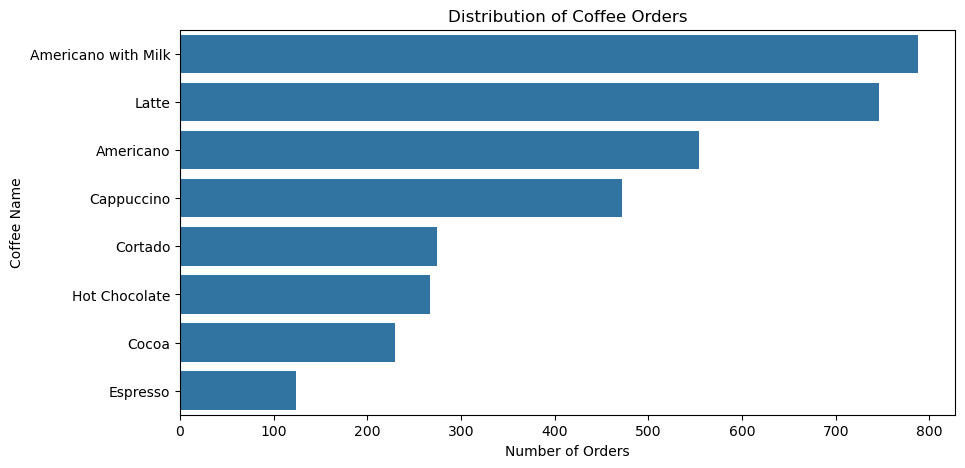

In [ ]:
# Target distribution: which drinks are most common?
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y="coffee_name", order=df["coffee_name"].value_counts().index)
plt.title("Distribution of Coffee Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Coffee Name")
plt.show()

# STEP 4: DATA CLEANING 

Data Cleaning makes the dataset more consistent and structured in a way such that the model can easily use it to make predictions. This is where we handle missing values, duplicates, inconsistent data types, and extreme values. 

1. Duplicates 
2. Data Types
3. Extreme Values 
4. Missing Values 

Pro tip: If we don't want to risk tarnishing the original dataset or if we want to rexplore something from a column we may have already dropped, it's best to make a cleaned copy of your DataFrame. 

In [27]:
cleaned_df = df.copy()
print("Original Shape:", cleaned_df.shape)
print("Duplicate Rows:", cleaned_df.duplicated().sum())

#let's make sure to drop duplicates if any so the model doesn't see the same data twice and get confused 
cleaned_df = cleaned_df.drop_duplicates()
print("New Shape (after dropping duplicates):", cleaned_df.shape)

Original Shape: (3636, 6)
Duplicate Rows: 0
New Shape (after dropping duplicates): (3636, 6)


In [28]:
#convert date and datetime cols --> actual datetime objects (not strings)
cleaned_df["date"] = pd.to_datetime(cleaned_df["date"])
cleaned_df["datetime"] = pd.to_datetime(cleaned_df["datetime"])
cleaned_df[['date', 'datetime']].head()

,date,datetime
0,2024-03-01,2024-03-01 10:15:50.520
1,2024-03-01,2024-03-01 12:19:22.539
2,2024-03-01,2024-03-01 12:20:18.089
3,2024-03-01,2024-03-01 13:46:33.006
4,2024-03-01,2024-03-01 13:48:14.626


In [29]:
#check for any impossible/extreme values 
#for example for the money column a negative value would be impossible 
print("Rows with missing datetime: ", cleaned_df["datetime"].isnull().sum())
print("Rows with missing date: ", cleaned_df["date"].isnull().sum())
print("Rows with negative money: ", (cleaned_df['money'] <= 0).sum())

# we want to keep only rows with valid datetime and positive money 
cleaned_df = cleaned_df.dropna(subset=["datetime", "date"])
cleaned_df = cleaned_df[cleaned_df['money'] > 0]
cleaned_df.shape



Rows with missing datetime:  0
Rows with missing date:  0
Rows with negative money:  0


(3636, 6)

In [30]:
# we can't train a model on data that isn't there, let's handle the missing values
target_col = "coffee_name" 
print("Missing values before handling:", cleaned_df[target_col].isnull().sum())
cleaned_df = cleaned_df.dropna(subset=[target_col]) # drop rows where target variable is missing (can't train on those)
print("Missing values after handling:", cleaned_df[target_col].isnull().sum())
print("Cleaned shape: ", cleaned_df.shape)

Missing values before handling: 182
Missing values after handling: 0
Cleaned shape:  (3454, 6)


In [31]:
#for our columns with strings as values, make sure the format is standardized (ie latte vs Latte --> standardize those)
for col in ['cash_type', 'coffee_name']:
    cleaned_df[col] = cleaned_df[col].astype(str).str.strip().str.lower()

cleaned_df[['cash_type', 'coffee_name']].head()

,cash_type,coffee_name
0,card,latte
1,card,hot chocolate
2,card,hot chocolate
3,card,americano
4,card,latte


# STEP 5: FEATURE ENGINEERING 
When we say "feature engineering", features are our variables (ie. our columns) and engineering those means transforming them in a way such that we can derive patterns from the data. What that entails in the scope of machine learning is that the input variables for the model should be formatted in order for the model to understand them the way a human does, so we are converting our columns to useful features by doing that. 

In [35]:
model_df = cleaned_df.copy()
model_df['hour'] = model_df['datetime'].dt.hour
model_df['day_of_week'] = model_df['datetime'].dt.day_name()
model_df["month"] = model_df["datetime"].dt.month
model_df["is_weekend"] = (model_df['datetime'].dt.dayofweek >= 5).astype(int) # 1 if weekend, 0 if weekday

#a broader time of day feature (ie morning, afternoon, evening, night)
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 17:
        return 'afternoon'
    elif 17 <= hour < 21:
        return 'evening'
    else:
        return 'night'
    
model_df['time_of_day'] = model_df['hour'].apply(get_time_of_day)
model_df[['datetime', 'hour', 'day_of_week', 'is_weekend', 'time_of_day']].head()

,datetime,hour,day_of_week,is_weekend,time_of_day
0,2024-03-01 10:15:50.520,10,Friday,0,morning
1,2024-03-01 12:19:22.539,12,Friday,0,afternoon
2,2024-03-01 12:20:18.089,12,Friday,0,afternoon
3,2024-03-01 13:46:33.006,13,Friday,0,afternoon
4,2024-03-01 13:48:14.626,13,Friday,0,afternoon


Let's quickly visualize how the new features we created relate to the target variable (coffee_name) to see if they might be useful for our model:

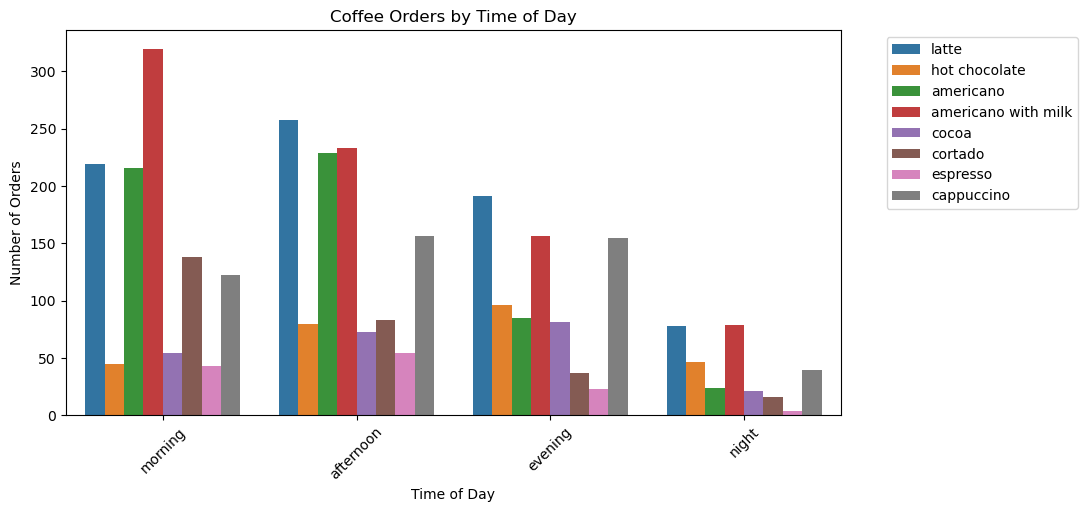

In [36]:
plt.figure(figsize=(10, 5))
sns.countplot(data=model_df, x="time_of_day", hue="coffee_name")
plt.title("Coffee Orders by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

# STEP 5.5: FEATURE SELECTION 
Here, our main goal is to just choose the columns that the model will be using. We want to avoid using columns that are overly specific like unique identifier columns, columns that are unavailable at the time of prediction, or columns that are too similar to the actual target. 

In [37]:
numeric_features = ["money", "hour", "month", "is_weekend"]
categorical_features = ["cash_type", "day_of_week", "time_of_day"]

features = numeric_features + categorical_features

X = model_df[features]
y = model_df[target_col]

print("Feature columns:", features)
print("Target column:", target_col)
print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

Feature columns: ['money', 'hour', 'month', 'is_weekend', 'cash_type', 'day_of_week', 'time_of_day']
Target column: coffee_name
X shape: (3454, 7)
y shape: (3454,)


,money,hour,month,is_weekend,cash_type,day_of_week,time_of_day
0,38.7,10,3,0,card,Friday,morning
1,38.7,12,3,0,card,Friday,afternoon
2,38.7,12,3,0,card,Friday,afternoon
3,28.9,13,3,0,card,Friday,afternoon
4,38.7,13,3,0,card,Friday,afternoon


# STEP 6: TRAIN / TEST SPLIT 
Our model needs to be trained on data in order to learn the patterns that exist within it and once we've created our model, we test it with examples of data that it hasn't seen before. In order to do this, we must split our data into "training" and "testing" data, where the training set teaches the model and the testing set estimates how the model will perform on real world / new data. The code for doing this is pretty standardized, a good practice is the 80/20 split (train/test). (Note: don't worry too much about random state, this is something we can leave to abstraction for building ML models)

In [39]:
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Training target distribution:")
print(y_train.value_counts(normalize=True).round(3))

Training rows: 2763
Testing rows: 691
Training target distribution:
coffee_name
americano with milk    0.228
latte                  0.216
americano              0.160
cappuccino             0.137
cortado                0.079
hot chocolate          0.077
cocoa                  0.066
espresso               0.036
Name: proportion, dtype: float64


# STEP 7: MODEL SELECTION 
We will break this step down a little further into the following: 
1. Preprocessing Pipeline 
2. Establishing a Baseline Model 
3. Model Selection and Training 



## Preprocessing Pipeline 

We know that machine learning models rely on inputs being quantitative, thus this step of creating a preprocessing pipeline handles both categorial and numeric features. 

1. Numeric features --> fill any missing values left and scale them 
2. Categorical features --> fill any missing values and one-hot encode them 

Question: We know that models need numeric variables so turning categorical features into those is what we call one-hot encoding. Identify a few examples of what columns could be one-hot encoded and HOW to one-hot encode different types of data. 

ANSWER: TODO

Here, we want to fit preprocessing on the training data only, then apply it to the testing data after. 

**Important Key Terms to Know:** 

imputing: filling missing values with other values in the data (ie filling nan with mean/mode/median)

StandardScalar() --> preprocessing tool from Pipeline to scale numeric variables 

ColumnTransformer() --> does exactly what it sounds like, transforms columns 

OneHotEncoder() --> same thing, one-hot encodes columns 

In [41]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['money', 'hour', 'month', 'is_weekend']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['cash_type', 'day_of_week', 'time_of_day'])])

## Baseline Model 

Before we train a real model, we want to build a simple baseline model to get us started and then we can tweak each feature weight, hyperparameters, and other metrics accordingly to improve our models accuracy. A baseline model should ideally answer the question of "How well could we do with a simple strategy?". This model will essentially always predict the most common drink (making it's accuracy the frequency of that drink in the data). 


In [42]:
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_preds)

print("Baseline accuracy:", round(baseline_accuracy, 3))
print("Most common class in training data:", y_train.value_counts().idxmax())

Baseline accuracy: 0.229
Most common class in training data: americano with milk


## Model Selection and Training 

Here, we will explore three different models and compare their performance to see which one is the best suited for our data. These are three of the most commonly used and simplest machine learning models. 

1. Logistic Regression: simple, interepretable classification model 
2. Decision Tree: rule-based model that can capture more non linear patterns 
3. Random Forest: ensemble of many decision trees, usually stronger but less interpretable 

In [43]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
}

results = []
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    
    trained_pipelines[name] = pipe
    results.append({"model": name, "test_accuracy": acc})

results_df = pd.DataFrame(results).sort_values("test_accuracy", ascending=False)
results_df

,model,test_accuracy
2,Random Forest,0.603473
1,Decision Tree,0.602026
0,Logistic Regression,0.557164


In [44]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_pipelines[best_model_name]

print("Best model:", best_model_name)

Best model: Random Forest


# STEP 8: MODEL EVALUATION 
This is where we see how well the model performs and where exactly it is failing. Accuracy is a good metric to give us a summary number, but the classification report and confusion matrix show performance by class which is helpful for our non-numeric columns especially. 

In [45]:
test_preds = best_model.predict(X_test)

print("Test accuracy:", round(accuracy_score(y_test, test_preds), 3))
print("Classification report:")
print(classification_report(y_test, test_preds))

Test accuracy: 0.603
Classification report:
                     precision    recall  f1-score   support

          americano       0.69      0.74      0.72       111
americano with milk       0.97      0.97      0.97       158
         cappuccino       0.36      0.38      0.37        94
              cocoa       0.26      0.24      0.25        46
            cortado       0.48      0.47      0.48        55
           espresso       1.00      0.68      0.81        25
      hot chocolate       0.40      0.36      0.38        53
              latte       0.47      0.48      0.48       149

           accuracy                           0.60       691
          macro avg       0.58      0.54      0.56       691
       weighted avg       0.61      0.60      0.60       691



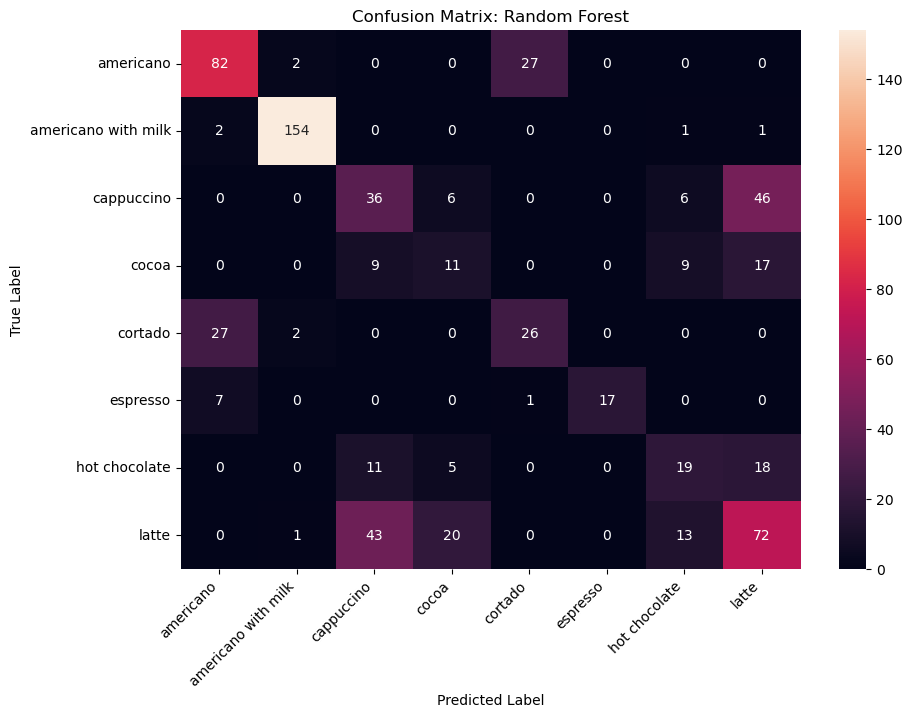

In [46]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, test_preds, labels=labels)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

Cross-Validation

One train/test split can be lucky or unlucky. Cross-validation trains and evaluates the model multiple times on different splits to get a more stable performance estimate.

In [47]:
cv_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

cv_scores = cross_val_score(cv_pipeline, X, y, cv=5, scoring="accuracy")

print("Cross-validation scores:", np.round(cv_scores, 3))
print("Mean CV accuracy:", round(cv_scores.mean(), 3))
print("CV standard deviation:", round(cv_scores.std(), 3))

Cross-validation scores: [0.22  0.347 0.459 0.566 0.588]
Mean CV accuracy: 0.436
CV standard deviation: 0.138


# Hyperparameter Tuning

Hyperparameters are settings we choose before training. Grid search tries combinations of settings and uses cross-validation to find the best one.

In [48]:
tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs"],
    "model__multi_class": ["auto"]
}

grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", round(grid_search.best_score_, 3))

final_model = grid_search.best_estimator_

/Users/nikithakerudi/miniforge3/envs/dsc80/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/nikithakerudi/miniforge3/envs/dsc80/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/nikithakerudi/miniforge3/envs/dsc80/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/nikithakerudi/miniforge3/envs/dsc80/lib/py

Best parameters: {'model__C': 10, 'model__multi_class': 'auto', 'model__solver': 'lbfgs'}
Best CV accuracy: 0.612


/Users/nikithakerudi/miniforge3/envs/dsc80/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [49]:
final_preds = final_model.predict(X_test)

print("Final tuned model test accuracy:", round(accuracy_score(y_test, final_preds), 3))
print("Final tuned model classification report:")
print(classification_report(y_test, final_preds))

Final tuned model test accuracy: 0.589
Final tuned model classification report:
                     precision    recall  f1-score   support

          americano       0.66      0.81      0.73       111
americano with milk       0.85      0.97      0.91       158
         cappuccino       0.28      0.22      0.25        94
              cocoa       0.00      0.00      0.00        46
            cortado       0.46      0.22      0.30        55
           espresso       0.96      0.92      0.94        25
      hot chocolate       0.00      0.00      0.00        53
              latte       0.43      0.72      0.54       149

           accuracy                           0.59       691
          macro avg       0.46      0.48      0.46       691
       weighted avg       0.50      0.59      0.53       691



In [51]:
#let's get our feature names from the preprocessor and coefficients from 
#the logistic regression model to see which features are most 
# important for predicting each drink

feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
log_reg = final_model.named_steps["model"]

coef_df = pd.DataFrame(
    log_reg.coef_,
    index=log_reg.classes_,
    columns=feature_names
)

# we can also show strongest positive features for each predicted drink
for drink in coef_df.index:
    print(f"Top features increasing prediction of: {drink}")
    display(coef_df.loc[drink].sort_values(ascending=False).head(5).to_frame("coefficient"))

Top features increasing prediction of: americano


,coefficient
cat__cash_type_cash,2.709423
cat__time_of_day_afternoon,0.509189
cat__day_of_week_Friday,0.312446
cat__day_of_week_Monday,0.166692
cat__day_of_week_Saturday,0.164179


Top features increasing prediction of: americano with milk


,coefficient
cat__cash_type_cash,0.329945
cat__day_of_week_Monday,0.209656
cat__time_of_day_night,0.201975
cat__day_of_week_Saturday,0.189658
cat__day_of_week_Tuesday,0.121849


Top features increasing prediction of: cappuccino


...

,coefficient
cat__cash_type_cash,5.083270
cat__time_of_day_afternoon,1.408054
cat__day_of_week_Friday,0.919339
num__hour,0.584054
cat__day_of_week_Sunday,0.188207


Top features increasing prediction of: hot chocolate


,coefficient
num__money,16.529613
num__month,3.781350
cat__cash_type_card,3.069086
cat__time_of_day_morning,0.657500
num__hour,0.532863


Top features increasing prediction of: latte


,coefficient
num__money,15.697978
num__month,3.742370
cat__cash_type_card,2.480019
cat__time_of_day_night,0.786646
cat__day_of_week_Monday,0.211071
